# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [3]:
# TODO : repartition de y (indice : value_counts + map vers CLASSES)
print(y.value_counts())

class
0    500
1    268
Name: count, dtype: int64


## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

arbre = DecisionTreeClassifier(max_depth=3,min_samples_leaf=10,criterion="gini",random_state=0) # TODO : creer et entrainer l'arbre
arbre.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=0)

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train : 0.783
Accuracy test  : 0.714
                precision    recall  f1-score   support

non_diabetique      0.750     0.840     0.792       125
    diabetique      0.615     0.478     0.538        67

      accuracy                          0.714       192
     macro avg      0.683     0.659     0.665       192
  weighted avg      0.703     0.714     0.704       192



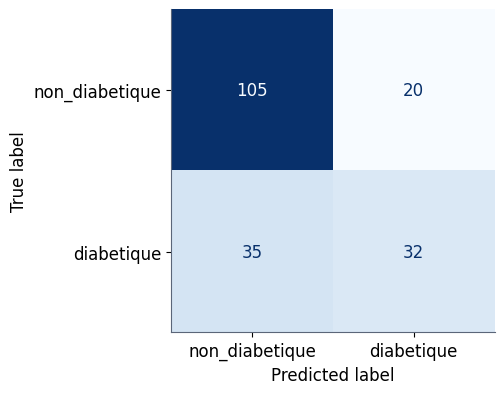

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TODO : accuracy train / test
print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")
y_pred = arbre.predict(X_test)

# TODO : afficher classification_report
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

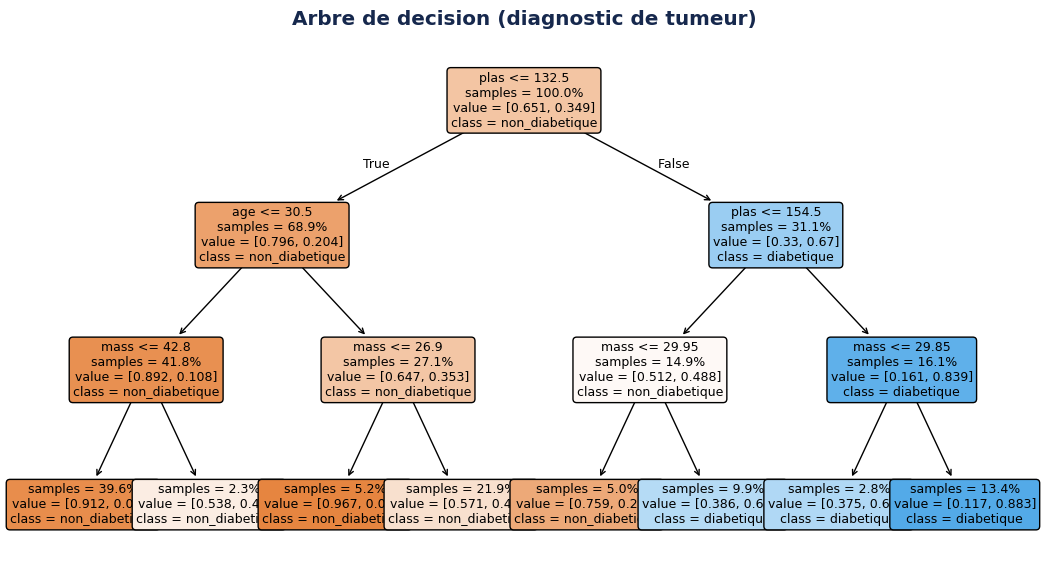

In [10]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
# TODO : plot_tree(arbre, feature_names=..., class_names=CLASSES, filled=True, ...)
plot_tree(arbre, feature_names=list(X.columns), class_names=CLASSES, filled=True,
          rounded=True, fontsize=9, impurity=False, proportion=True, ax=ax)
ax.set_title("Arbre de decision (diagnostic de tumeur)")

plt.show()

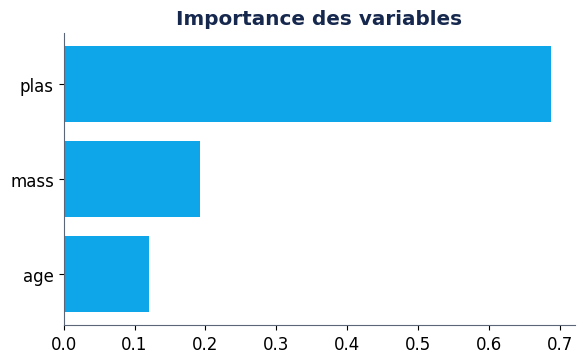

In [12]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()

# TODO : barh de imp
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
ax.set_title("Importance des variables")

plt.show()



## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [14]:
ech = X_test.head(5)

# TODO : pred et proba, puis DataFrame comparatif
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_benin": proba.round(2),
})

,reel,predit,proba_benin
0,diabetique,non_diabetique,0.43
1,non_diabetique,non_diabetique,0.09
2,non_diabetique,non_diabetique,0.09
3,diabetique,diabetique,0.61
4,diabetique,diabetique,0.88


## A rendre
- Accuracy test + lecture de la matrice de confusion.
    Accuracy test : 0.714 (71,4%), vs train 0.783 : un léger surapprentissage mais pas énorme.

    Matrice de confusion : 192 dans le cas test - sur 67 diabétiques réels, modèle en repère correctement seulement ~32 (rappel 0.478), en rate ~35 (faux négatifs). Sur 125 non-diabétiques, ~105 bien classés (rappel 0.840), 20 faux positifs. Modèle plus performant pour repérer classe négative que classe positive.

- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
    0.478 (précision 0.615, f1 0.538) — faible: modèle rate plus de la moitié des vrais diabétiques.

- Les 2-3 variables les plus determinantes.
    1. plas (glycémie plasmatique) — largement dominante, ~0.69
    2. mass (BMI) — ~0.19
    3. age — ~0.12

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?


**`Random Forest`**

Accuracy train : 0.799
Accuracy test  : 0.719
                precision    recall  f1-score   support

non_diabetique      0.738     0.880     0.803       125
    diabetique      0.651     0.418     0.509        67

      accuracy                          0.719       192
     macro avg      0.695     0.649     0.656       192
  weighted avg      0.708     0.719     0.700       192



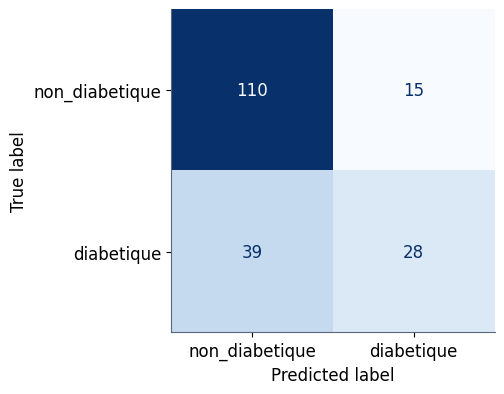

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=10,
    criterion="gini",
    random_state=0,
)
rf.fit(X_train, y_train)

print(f"Accuracy train : {rf.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {rf.score(X_test, y_test):.3f}")

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=CLASSES, digits=3))

cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm_rf, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

**XG Boost**

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, random_state=0, eval_metric="logloss")
xgb.fit(X_train, y_train)

print(f"Accuracy train : {xgb.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {xgb.score(X_test, y_test):.3f}")

Accuracy train : 1.000
Accuracy test  : 0.729
